In [1]:
import numpy as np
import matplotlib.pyplot as plt

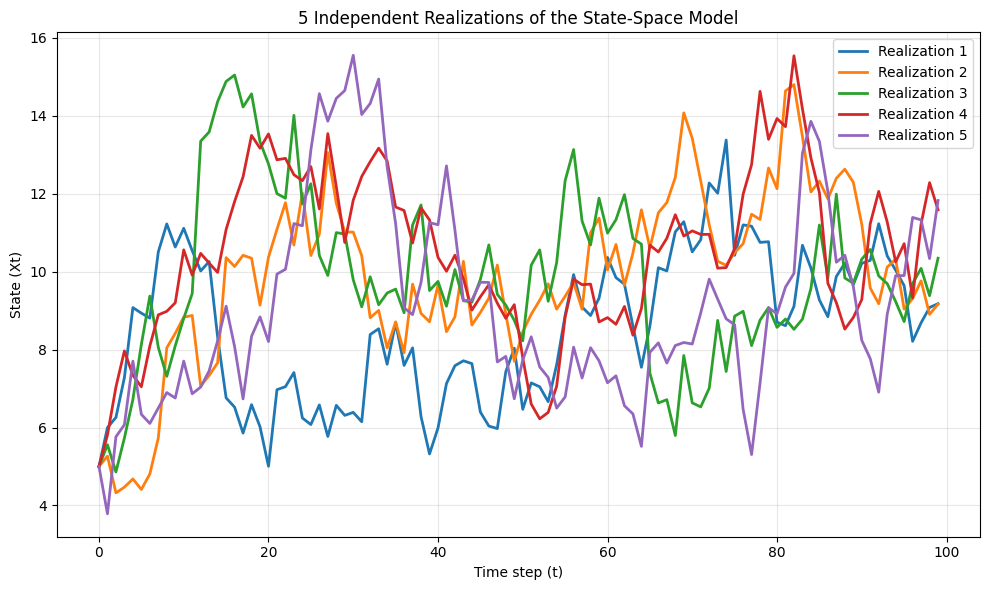

In [2]:
# 1.1

np.random.seed(42)

n = 100
a = 0.9
b = 1
sigma_1 = 1
X0 = 5
num_realizations = 5

realizations = np.zeros((num_realizations, n))

for realization in range(num_realizations):
    X = np.zeros(n)
    X[0] = X0
    for t in range(1, n):
        e_t = np.random.normal(0, sigma_1)
        X[t] = a * X[t-1] + b + e_t
    realizations[realization] = X

plt.figure(figsize=(10, 6))
for i in range(num_realizations):
    plt.plot(realizations[i], label=f"Realization {i+1}", linewidth=2)

plt.xlabel("Time step (t)")
plt.ylabel('State (Xt)')
plt.title('5 Independent Realizations of the State-Space Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

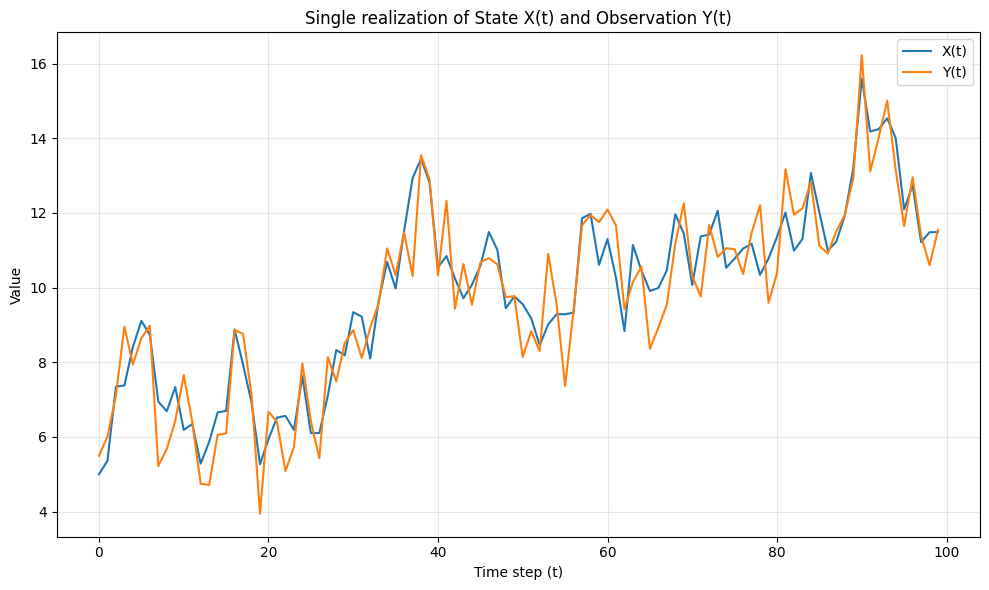

In [3]:
# 1.2

np.random.seed(42)

n = 100
a = 0.9
b = 1
sigma_1 = 1
X0 = 5

X = np.zeros(n)
X[0] = X0

Y = np.zeros(n)
Y[0] = X[0] + np.random.normal(0, 1)

for t in range(1, n):
    e1_t = np.random.normal(0, sigma_1)
    e2_t = np.random.normal(0, 1)
    X[t] = a * X[t-1] + b + e1_t
    Y[t] = X[t] + e2_t

plt.figure(figsize=(10, 6))
plt.xlabel("Time step (t)")
plt.ylabel("Value")
plt.plot(X, label="X(t)")
plt.plot(Y, label="Y(t)")
plt.title("Single realization of State X(t) and Observation Y(t)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



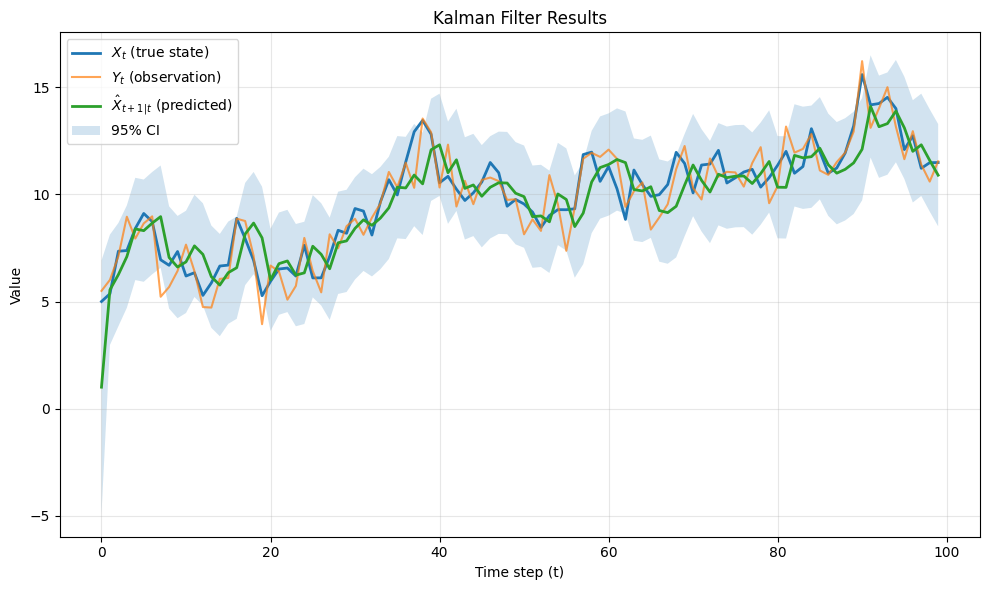

In [4]:
# 1.3

# From the kalmanfilter.R file, translated to Python
def myKalmanFilter(y, theta, R, x_prior=0, P_prior=10):
    """
    Kalman filter for 1D state-space model
    X_{t+1} = a*X_t + b + e_t
    Y_t = X_t + e_{2,t}
    
    Args:
        y: Vector of observations
        theta: Model parameters [a, b, sigma1]
        R: Measurement noise variance
        x_prior: Initial prior mean for X_0
        P_prior: Initial prior variance for X_0
    
    Returns:
        Dictionary with predicted/filtered states and innovations
    """
    a = theta[0]
    b = theta[1]
    sigma1 = theta[2]
    N = len(y)
    
    x_pred = np.zeros(N)           # Predicted means
    P_pred = np.zeros(N)           # Predicted variances
    x_filt = np.zeros(N)           # Filtered means
    P_filt = np.zeros(N)           # Filtered variances
    innovation = np.zeros(N)       # Pre-fit residuals: y[t] - x_pred[t]
    innovation_var = np.zeros(N)   # Innovation covariance: P_pred[t] + R
    
    for t in range(N):
        # Prediction step
        if t == 0:
            x_pred[t] = a * x_prior + b                    # Mean prediction using prior
            P_pred[t] = a**2 * P_prior + sigma1**2         # Variance prediction using prior
        else:
            x_pred[t] = a * x_filt[t-1] + b                # Mean prediction using previous filtered estimate
            P_pred[t] = a**2 * P_filt[t-1] + sigma1**2     # Variance prediction using previous filtered estimate
        
        # Update step
        innovation[t] = y[t] - x_pred[t]                   # Prediction error
        innovation_var[t] = P_pred[t] + R                  # Prediction error variance
        K_t = P_pred[t] / innovation_var[t]                # Kalman gain
        x_filt[t] = x_pred[t] + K_t * innovation[t]        # Filtered estimate
        P_filt[t] = (1 - K_t) * P_pred[t]                  # Filtered estimate variance
    
    return {
        'x_pred': x_pred,
        'P_pred': P_pred,
        'x_filt': x_filt,
        'P_filt': P_filt,
        'innovation': innovation,
        'innovation_var': innovation_var
    }

kf_results = myKalmanFilter(Y, [a, b, sigma_1], R=1)
x_pred = kf_results['x_pred']
P_pred = kf_results['P_pred']

ci_95 = 1.96 * np.sqrt(P_pred)

plt.figure(figsize=(10, 6))
plt.plot(X, label=r"$X_t$ (true state)", linewidth=2)
plt.plot(Y, label=r"$Y_t$ (observation)", alpha=0.7)
plt.plot(x_pred, label=r"$\hat{X}_{t+1|t}$ (predicted)", linewidth=2)
plt.fill_between(range(n), x_pred - ci_95, x_pred + ci_95, alpha=0.2, label="95% CI")

plt.xlabel("Time step (t)")
plt.ylabel("Value")
plt.title("Kalman Filter Results")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



 True params: a=0.9, b=1, σ1=1
Estimated a: 0.844 ± 0.072
Estimated b: 1.543 ± 0.700
Estimated σ1: 1.014 ± 0.167

 True params: a=0.9, b=5, σ1=1
Estimated a: 0.906 ± 0.026
Estimated b: 4.694 ± 1.265
Estimated σ1: 1.016 ± 0.235

 True params: a=0.9, b=1, σ1=5
Estimated a: 0.846 ± 0.068
Estimated b: 1.564 ± 0.897
Estimated σ1: 4.943 ± 0.350


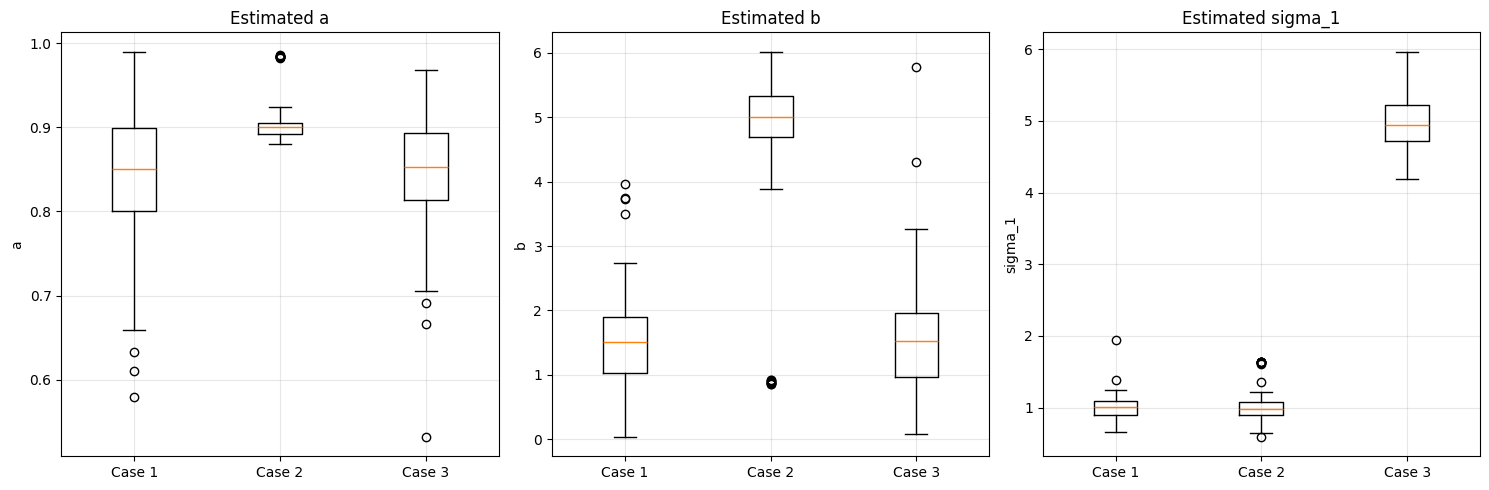

In [5]:
# 1.4

def myLogLikFun(theta, y, R, x_prior=0, P_prior=10):
    kf_results = myKalmanFilter(y, theta, R, x_prior, P_prior)
    err = kf_results['innovation']
    S = kf_results['innovation_var']

    # Compute log-likelihood contributions from each time step
    logL = -0.5 * np.sum(np.log(2 * np.pi * S) + (err**2) / S)

    # Return negative log-likelihood for minimization
    return -logL


from scipy.optimize import minimize

# Parameter combinations to test
param_combinations = [
    {'a': 0.9, 'b': 1, 'sigma_1': 1},
    {'a': 0.9, 'b': 5, 'sigma_1': 1},
    {'a': 0.9, 'b': 1, 'sigma_1': 5},
]

# Storage for results
all_estimates = []

for params in param_combinations:
    a_true = params['a']
    b_true = params['b']
    sigma1_true = params['sigma_1']
    
    estimates = {'a': [], 'b': [], 'sigma_1': []}
    
    # Simulate 100 independent realizations
    for sim in range(100):
        np.random.seed(sim)  # Different seed for each simulation
        
        # Simulate system
        X_sim = np.zeros(n)
        X_sim[0] = X0
        Y_sim = np.zeros(n)
        Y_sim[0] = X_sim[0] + np.random.normal(0, 1)
        
        for t in range(1, n):
            e1_t = np.random.normal(0, sigma1_true)
            e2_t = np.random.normal(0, 1)
            X_sim[t] = a_true * X_sim[t-1] + b_true + e1_t
            Y_sim[t] = X_sim[t] + e2_t
        
        # Estimate parameters by minimizing negative log-likelihood
        initial_guess = np.array([0.5, 0.5, 1.0])
        bounds = [(0.01, 0.99), (-10, 10), (0.1, 10)]  # Parameter bounds
        
        result = minimize(
            myLogLikFun,
            initial_guess,
            args=(Y_sim, 1, 0, 10),
            method='L-BFGS-B',
            bounds=bounds
        )
        
        if result.success:
            estimates['a'].append(result.x[0])
            estimates['b'].append(result.x[1])
            estimates['sigma_1'].append(result.x[2])
    
    all_estimates.append(estimates)
    
    # Print summary
    print(f"\n True params: a={a_true}, b={b_true}, σ1={sigma1_true}")
    print(f"Estimated a: {np.mean(estimates['a']):.3f} ± {np.std(estimates['a']):.3f}")
    print(f"Estimated b: {np.mean(estimates['b']):.3f} ± {np.std(estimates['b']):.3f}")
    print(f"Estimated σ1: {np.mean(estimates['sigma_1']):.3f} ± {np.std(estimates['sigma_1']):.3f}")

# Create boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, param_name) in enumerate(zip(axes, ['a', 'b', 'sigma_1'])):
    data = [est[param_name] for est in all_estimates]
    ax.boxplot(data, tick_labels=[f"Case {j+1}" for j in range(3)])
    ax.set_ylabel(param_name)
    ax.set_title(f'Estimated {param_name}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


=== Task 1.5: Robustness to Non-Gaussian Noise ===



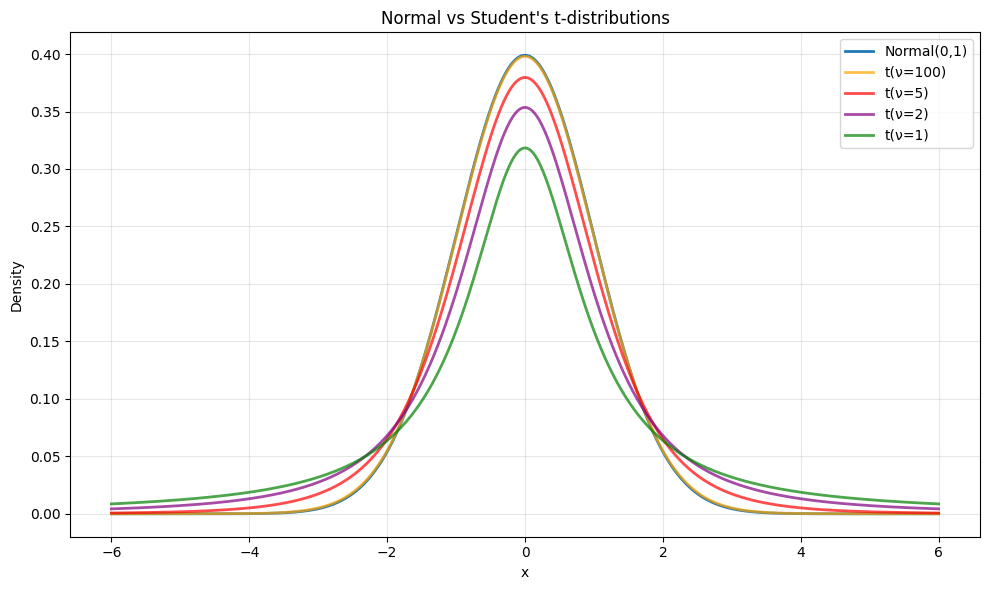


Estimating parameters with t-distributed system noise (ν=100):
Estimated a: 0.845 ± 0.069
Estimated b: 1.508 ± 0.672
Estimated σ1: 1.042 ± 0.247

Estimating parameters with t-distributed system noise (ν=5):
Estimated a: 0.841 ± 0.078
Estimated b: 1.545 ± 0.748
Estimated σ1: 1.296 ± 0.299

Estimating parameters with t-distributed system noise (ν=2):
Estimated a: 0.841 ± 0.062
Estimated b: 1.549 ± 0.652
Estimated σ1: 2.539 ± 0.978

Estimating parameters with t-distributed system noise (ν=1):
Estimated a: 0.867 ± 0.050
Estimated b: 1.058 ± 4.150
Estimated σ1: 8.415 ± 2.262


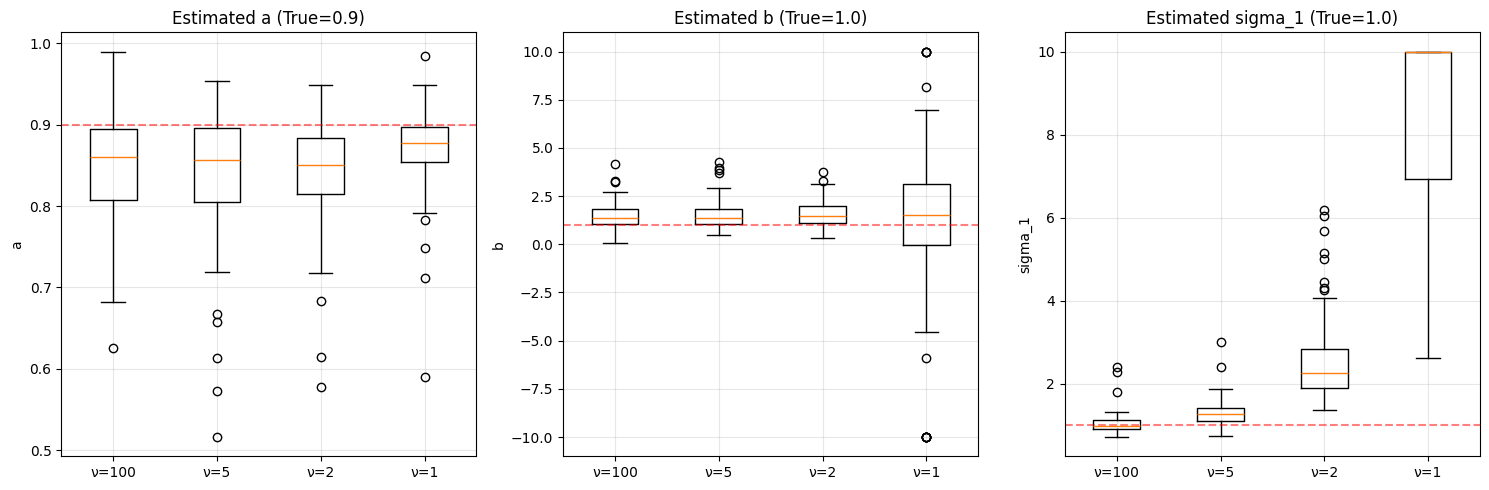

In [6]:
# 1.5 - Robustness to Non-Gaussian Noise (Student's t-distributed system noise)

from scipy.stats import t as t_dist

# Degrees of freedom to test
nu_values = [100, 5, 2, 1]

# Storage for results from t-distributed noise
t_noise_estimates = {nu: {'a': [], 'b': [], 'sigma_1': []} for nu in nu_values}

# Use one of the parameter combinations (e.g., first one: a=0.9, b=1, sigma_1=1)
a_true = 0.9
b_true = 1.0
sigma1_true = 1.0

print("\n=== Task 1.5: Robustness to Non-Gaussian Noise ===\n")

# First, plot t-distribution vs Normal distribution
fig_dist, ax_dist = plt.subplots(figsize=(10, 6))
x_vals = np.linspace(-6, 6, 1000)
ax_dist.plot(x_vals, 1/np.sqrt(2*np.pi) * np.exp(-x_vals**2/2), label='Normal(0,1)', linewidth=2)

colors = ['orange', 'red', 'purple', 'green']
for nu, color in zip(nu_values, colors):
    ax_dist.plot(x_vals, t_dist.pdf(x_vals, nu), label=f't(ν={nu})', linewidth=2, color=color, alpha=0.7)

ax_dist.set_xlabel('x')
ax_dist.set_ylabel('Density')
ax_dist.set_title('Normal vs Student\'s t-distributions')
ax_dist.legend()
ax_dist.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estimate parameters for each degree of freedom
for nu in nu_values:
    print(f"\nEstimating parameters with t-distributed system noise (ν={nu}):")
    
    for sim in range(100):
        np.random.seed(sim)
        
        # Simulate system with t-distributed system noise
        X_sim = np.zeros(n)
        X_sim[0] = X0
        Y_sim = np.zeros(n)
        Y_sim[0] = X_sim[0] + np.random.normal(0, 1)
        
        for t in range(1, n):
            # t-distributed system noise scaled by sigma_1
            e1_t = sigma1_true * t_dist.rvs(nu)
            e2_t = np.random.normal(0, 1)
            X_sim[t] = a_true * X_sim[t-1] + b_true + e1_t
            Y_sim[t] = X_sim[t] + e2_t
        
        # Apply Kalman filter (which assumes Gaussian noise) to t-distributed data
        initial_guess = np.array([0.5, 0.5, 1.0])
        bounds = [(0.01, 0.99), (-10, 10), (0.1, 10)]
        
        result = minimize(
            myLogLikFun,
            initial_guess,
            args=(Y_sim, 1, 0, 10),
            method='L-BFGS-B',
            bounds=bounds
        )
        
        if result.success:
            t_noise_estimates[nu]['a'].append(result.x[0])
            t_noise_estimates[nu]['b'].append(result.x[1])
            t_noise_estimates[nu]['sigma_1'].append(result.x[2])
    
    print(f"Estimated a: {np.mean(t_noise_estimates[nu]['a']):.3f} ± {np.std(t_noise_estimates[nu]['a']):.3f}")
    print(f"Estimated b: {np.mean(t_noise_estimates[nu]['b']):.3f} ± {np.std(t_noise_estimates[nu]['b']):.3f}")
    print(f"Estimated σ1: {np.mean(t_noise_estimates[nu]['sigma_1']):.3f} ± {np.std(t_noise_estimates[nu]['sigma_1']):.3f}")

# Create boxplots comparing parameter estimates across degrees of freedom
fig_box, axes_box = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, param_name) in enumerate(zip(axes_box, ['a', 'b', 'sigma_1'])):
    data = [t_noise_estimates[nu][param_name] for nu in nu_values]
    ax.boxplot(data, tick_labels=[f"ν={nu}" for nu in nu_values])
    ax.set_ylabel(param_name)
    ax.set_title(f'Estimated {param_name} (True={[a_true, b_true, sigma1_true][i]})')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=[a_true, b_true, sigma1_true][i], color='r', linestyle='--', alpha=0.5, label='True value')

plt.tight_layout()
plt.show()